# HGNet Occlusion Landmark 복원 진단

masked gaze 병목(model4 0.546 vs hyi 0.582) 원인 분석용.
**핵심 질문: 가려진 region(눈/입)에서 HGNet이 좌표를 얼마나 복원하나?**

- 데이터: `region_occlusion_video_dataset_v3_original_fixedmask` (region × 8 appearance)
- region 폴더(both_eyes/left_eye/right_eye/mouth) = **가려진 부위 = 평가 대상 region**
- GT = clean(가림 없는) mediapipe facemesh 좌표
- 추론: ORFormer+HGNet (단, ORFormer reference 는 기여 0으로 확인됨 → 사실상 HGNet)
- 목적: 재학습 필요성/방향 결정 (어떤 부위·어떤 appearance 가 무너지나)

In [1]:
import sys, re, glob, importlib.util as ilu
import numpy as np, torch, cv2
from pathlib import Path
import matplotlib.pyplot as plt

DEV = "cuda" if torch.cuda.is_available() else "cpu"
R = Path("/home/yg/fusion/pretrain_v4")
for p in ["configs", "src/data", "src"]:
    sys.path.insert(0, str(R / p))
sys.path.insert(0, "/data/shared/orformer/vendor")
from default import get_cfg
from heatmap_gen import denorm_points
from models.VQVAE import VQVAE
from models.simple_vit import ORFormer
from models.StackedHGNet import IntergrationStackedHGNet
import torchvision.transforms as T
import models.quantizer as _q
_q.device = torch.device(DEV)
NORM = T.Compose([T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
cfg = get_cfg(); cfg.DMD.GT_SOURCE = "mediapipe"; ds = cfg.DMD
print("device:", DEV)

device: cuda


In [2]:
# region landmark index
s = ilu.spec_from_file_location("fr7", "/data/shared/scuppy/Gaze_image_model/src/data/face_regions7.py")
fr7 = ilu.module_from_spec(s); s.loader.exec_module(fr7); FR = fr7.FACE_REGIONS_7
LE = np.array(sorted(set(FR["left_eye"])  | set(range(468,473))))
RE = np.array(sorted(set(FR["right_eye"]) | set(range(473,478))))
MO = np.array(sorted(set(FR["mouth"])))
IRIS = np.arange(468,478)
REGION_IDX = {"left_eye":LE, "right_eye":RE, "mouth":MO, "both_eyes":np.union1d(LE,RE)}
ALL = np.arange(478)
print({k:len(v) for k,v in REGION_IDX.items()}, "iris", len(IRIS))

{'left_eye': 31, 'right_eye': 31, 'mouth': 40, 'both_eyes': 62} iris 10


In [3]:
# 모델 로드
vit = ORFormer(image_size=16, patch_size=1, num_classes=2048, dim=256, depth=3, heads=8, mlp_dim=512, channels=256)
orf = VQVAE(h_dim=128, res_h_dim=32, output_dim=ds.NUM_EDGE, n_res_layers=2, n_embeddings=2048,
            embedding_dim=256, code_dim=256, beta=0.25, vit=vit).to(DEV).eval()
orf.load_state_dict(torch.load(str(R/"artifacts/phase2_orformer_fixed/best.pt"), map_location=DEV, weights_only=False).get("model_state_dict"), strict=False)
hg = IntergrationStackedHGNet(classes_num=[ds.NUM_POINT, ds.NUM_EDGE, ds.NUM_POINT],
                              edge_info=[list(x) for x in ds.EDGE_INFO], nstack=4).to(DEV).eval()
hg.load_state_dict(torch.load(str(R/"artifacts/phase3a_hgnet_478/best.pt"), map_location=DEV, weights_only=False)["hgnet_state_dict"], strict=True)
print("loaded")

@torch.no_grad()
def predict(crop112):
    rgb = np.stack([cv2.resize(crop112,(256,256))]*3,-1)
    res = cv2.resize(rgb,(64,64))
    _, ref, *_ = orf(NORM(res).unsqueeze(0).to(DEV))
    _, lm = hg(NORM(rgb).unsqueeze(0).to(DEV), reference_heatmaps=ref)
    return denorm_points(lm,64,64)[0].cpu().numpy()*(112/64)

def crop_gt(frame, bb, gt_full, pad=0.1, sz=112):
    x1,y1,x2,y2 = bb; cx,cy=(x1+x2)/2,(y1+y2)/2; s=max(x2-x1,y2-y1)*(1+2*pad)
    ax,ay=cx-s/2,cy-s/2; h,w=frame.shape[:2]
    a,b=max(0,int(ax)),max(0,int(ay)); a2,b2=min(w,int(cx+s/2)),min(h,int(cy+s/2))
    c=frame[b:b2,a:a2]
    if c.size==0: return None,None
    if c.ndim==3: c=cv2.cvtColor(c,cv2.COLOR_BGR2GRAY)
    return cv2.resize(c,(sz,sz)), (gt_full-np.array([ax,ay]))*(sz/s)

def nme(pred, gt, idx):
    al,ar = ds.NME_ANCHOR
    d = max(np.linalg.norm(gt[al]-gt[ar]),1e-6)
    return np.linalg.norm(pred[idx]-gt[idx],axis=1).mean()/d*100

loaded


In [4]:
# 샘플 수집: region(가린 부위) × appearance
VID="/data/shared/Occlusion_subset_dataset/region_occlusion_video_dataset_v3_original_fixedmask/videos"
BB ="/data/shared/Occlusion_subset_dataset/region_occlusion_video_dataset_v3_original_fixedmask_yolo_face_facemesh/yolo_face"
FM ="/data/shared/DMD_landmarks/facemesh"
APPS=["solid","soft_solid","blur_patch","smooth_noise","soft_noise","noise","checker","stripe"]
REGIONS=["left_eye","right_eye","mouth","both_eyes"]
N_VID=2; N_FRAME=4   # region×app 당 영상/frame (속도조절)

samples=[]  # dict: region, app, crop, pred, gt
for region in REGIONS:
    for app in APPS:
        for vid in sorted(glob.glob(f"{VID}/{region}/{app}/*.mp4"))[:N_VID]:
            name=Path(vid).stem
            m=re.search(r'(g[A-Z]_\d+_s\d+_[0-9T;:+-]+)_ir_face', name)
            if not m: continue
            bbf=f"{BB}/{region}/{app}/{name}_face5pt.npz"
            cf=glob.glob(f"{FM}/**/{m.group(1)}_ir_face_facemesh.npz", recursive=True)
            if not Path(bbf).exists() or not cf: continue
            zb=np.load(bbf,allow_pickle=True); bbox=zb["bbox"]; det=zb["detected"].astype(bool)
            zc=np.load(cf[0],allow_pickle=True); clean=zc["landmarks"]; cdet=zc["detected"].astype(bool)
            cap=cv2.VideoCapture(vid)
            valid=np.where(det & cdet[:len(det)])[0]
            if len(valid)==0: cap.release(); continue
            for fi in valid[np.linspace(0,len(valid)-1,N_FRAME,dtype=int)]:
                cap.set(cv2.CAP_PROP_POS_FRAMES,int(fi)); ok,fr=cap.read()
                if not ok: continue
                crop,gt=crop_gt(fr,bbox[fi],clean[fi][:,:2])
                if crop is None or not np.isfinite(gt).all(): continue
                samples.append(dict(region=region,app=app,crop=crop,pred=predict(crop),gt=gt))
            cap.release()
print("samples:", len(samples))

samples: 244


## 1. 가려진 region NME 표 (region × appearance)
**NME 는 '가려진 부위'에서만 측정** — 그 부위는 appearance 단서가 없어 HGNet 이 구조로 복원해야 함.

In [5]:
import collections
# region(가린부위) 의 index 로 NME
def occ_idx(region): return REGION_IDX[region]
table=collections.defaultdict(list)        # (region,app) -> occluded NME
iris_tab=collections.defaultdict(list)      # both_eyes iris NME
for sp in samples:
    idx=occ_idx(sp["region"])
    table[(sp["region"],sp["app"])].append(nme(sp["pred"],sp["gt"],idx))
    if sp["region"]=="both_eyes":
        iris_tab[sp["app"]].append(nme(sp["pred"],sp["gt"],IRIS))

print(f"{'region':<10}", *[f"{a[:6]:>8}" for a in APPS]); print("-"*82)
for region in REGIONS:
    row=[np.mean(table[(region,a)]) if table[(region,a)] else float('nan') for a in APPS]
    print(f"{region:<10}", *[f"{v:>8.1f}" for v in row])
print("\nNME 해석(IPD 정규화 %): <5 양호, 5~10 흐림, >10 사실상 실패")

region        solid   soft_s   blur_p   smooth   soft_n    noise   checke   stripe
----------------------------------------------------------------------------------
left_eye        5.4      5.6     17.3      7.9      6.6      2.5      9.3      5.3
right_eye       7.3     11.2     12.2      7.0      5.7     12.8      3.6     19.5
mouth           9.6      9.3     12.4     23.7     15.4     15.9     19.5     12.6
both_eyes      11.3     30.9     14.1     12.7     14.0     24.0     96.4     35.4

NME 해석(IPD 정규화 %): <5 양호, 5~10 흐림, >10 사실상 실패


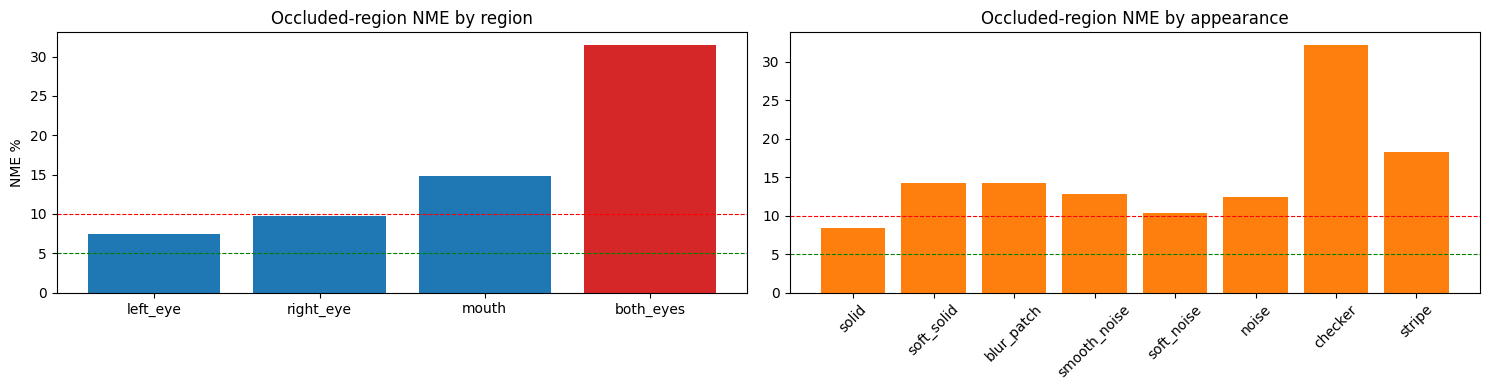

In [6]:
# region별 평균 + appearance별 평균 막대
fig,ax=plt.subplots(1,2,figsize=(15,4))
rmean=[np.mean([v for (rg,_),vs in table.items() if rg==region for v in vs]) for region in REGIONS]
ax[0].bar(REGIONS,rmean,color=["#d62728" if r=="both_eyes" else "#1f77b4" for r in REGIONS])
ax[0].set_title("Occluded-region NME by region"); ax[0].set_ylabel("NME %"); ax[0].axhline(5,ls="--",c="g",lw=.8); ax[0].axhline(10,ls="--",c="r",lw=.8)
amean=[np.mean([v for (_,ap),vs in table.items() if ap==a for v in vs]) for a in APPS]
ax[1].bar(APPS,amean,color="#ff7f0e"); ax[1].set_title("Occluded-region NME by appearance"); ax[1].axhline(5,ls="--",c="g",lw=.8); ax[1].axhline(10,ls="--",c="r",lw=.8)
ax[1].tick_params(axis="x",rotation=45)
plt.tight_layout(); plt.show()

## 2. 좌표 오버레이 — 가려진 부위 GT(초록) vs HGNet 예측(빨강)
가린 region landmark 를 강조. 예측이 GT 에서 멀면 복원 실패.

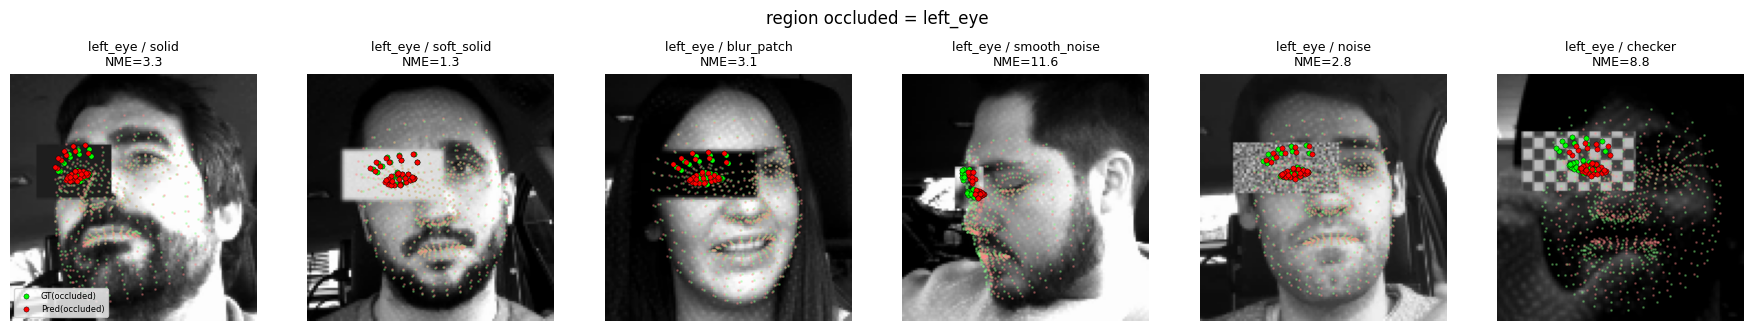

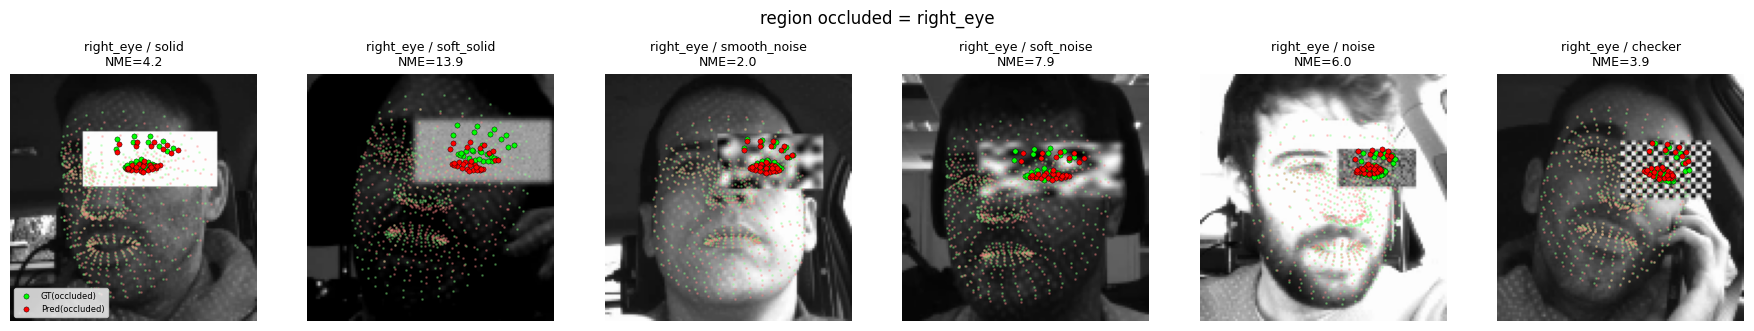

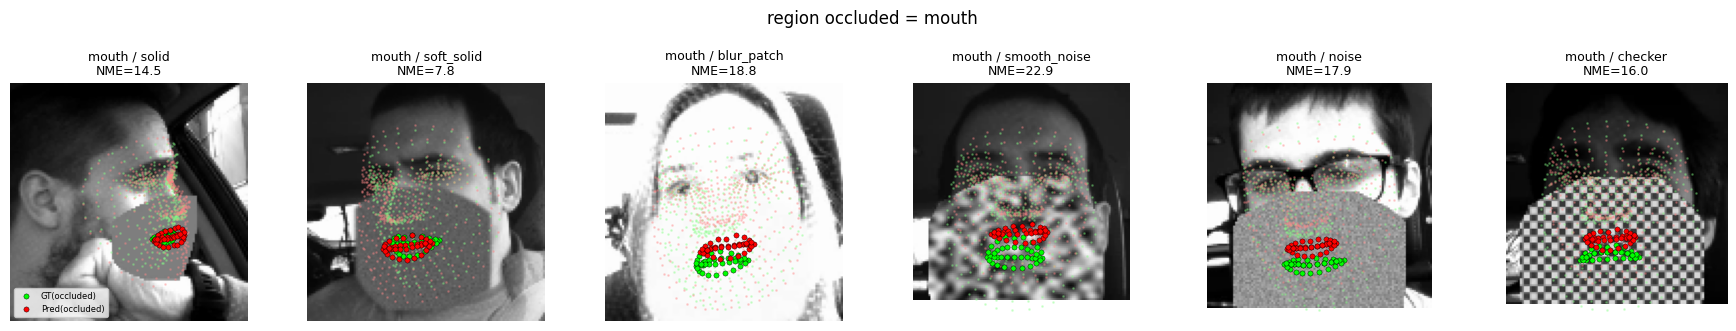

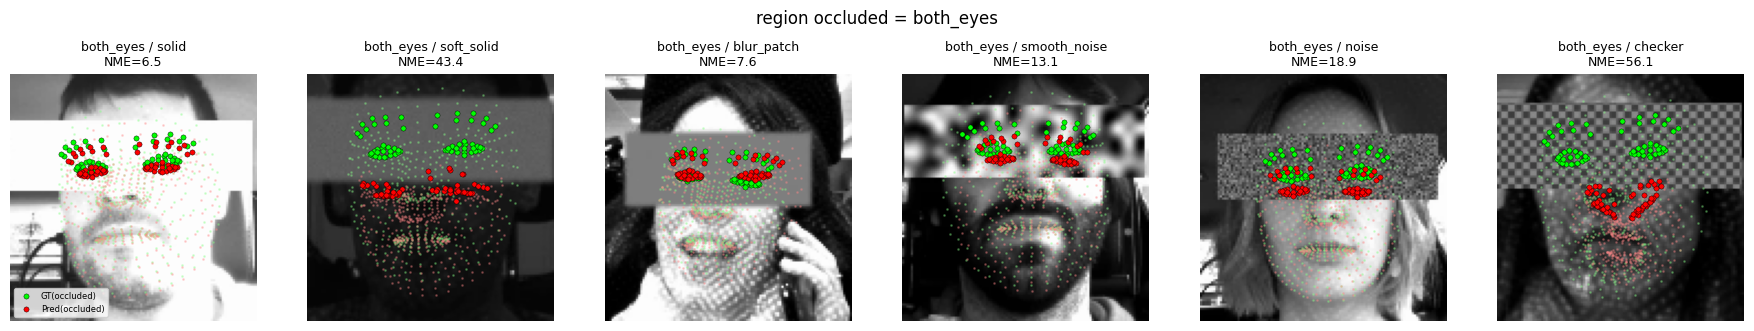

In [7]:
def overlay(sp, ax):
    img=cv2.cvtColor(sp["crop"],cv2.COLOR_GRAY2RGB)
    ax.imshow(img,cmap="gray")
    idx=occ_idx(sp["region"]); other=np.setdiff1d(ALL,idx)
    # 가시 부위는 옅게
    ax.scatter(sp["gt"][other,0],sp["gt"][other,1],s=1,c="#88ff88",alpha=.3)
    ax.scatter(sp["pred"][other,0],sp["pred"][other,1],s=1,c="#ff8888",alpha=.3)
    # 가린 부위 강조
    ax.scatter(sp["gt"][idx,0],sp["gt"][idx,1],s=14,c="lime",label="GT(occluded)",edgecolors="k",linewidths=.3)
    ax.scatter(sp["pred"][idx,0],sp["pred"][idx,1],s=14,c="red",label="Pred(occluded)",edgecolors="k",linewidths=.3)
    ax.set_title(f"{sp['region']} / {sp['app']}\nNME={nme(sp['pred'],sp['gt'],idx):.1f}",fontsize=9)
    ax.axis("off")

# 각 region 대표 샘플 (appearance 다양)
for region in REGIONS:
    subs=[sp for sp in samples if sp["region"]==region]
    pick=subs[::max(1,len(subs)//6)][:6]
    fig,axes=plt.subplots(1,len(pick),figsize=(3*len(pick),3.2))
    if len(pick)==1: axes=[axes]
    for sp,ax in zip(pick,axes): overlay(sp,ax)
    axes[0].legend(loc="lower left",fontsize=6)
    fig.suptitle(f"region occluded = {region}",y=1.02); plt.tight_layout(); plt.show()

## 3. 최악 케이스 — both_eyes 의 iris 복원
양눈 동시 가림 = iris 단서 완전 소실. gaze 핵심인 iris(468~477) NME 집중 점검.

both_eyes IRIS NME (gaze 핵심):
  solid        iris NME=11.4
  soft_solid   iris NME=29.1
  blur_patch   iris NME=13.2
  smooth_noise iris NME=13.1
  soft_noise   iris NME=13.2
  noise        iris NME=23.8
  checker      iris NME=93.7
  stripe       iris NME=34.1


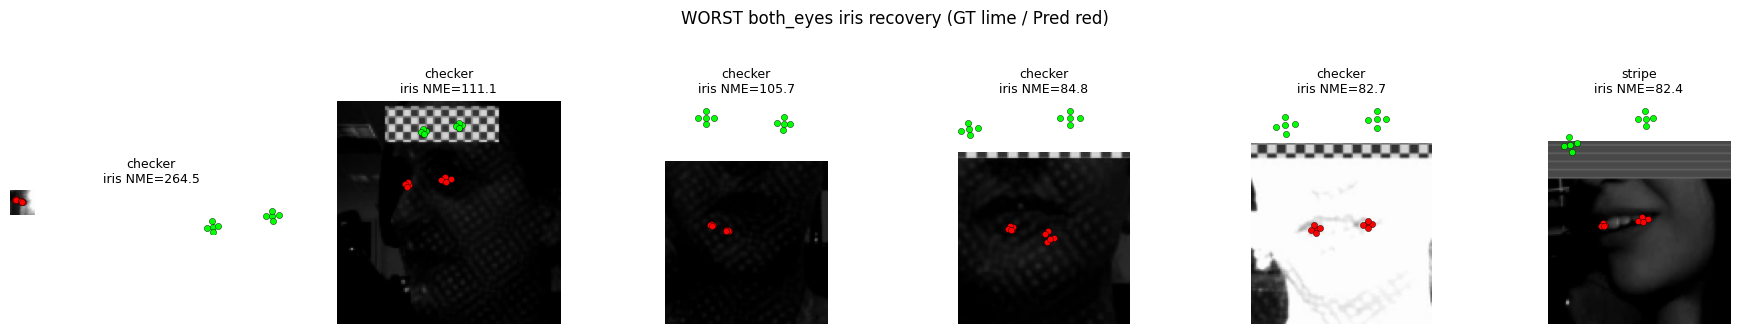

In [8]:
print("both_eyes IRIS NME (gaze 핵심):")
for a in APPS:
    if iris_tab[a]: print(f"  {a:<12} iris NME={np.mean(iris_tab[a]):.1f}")
# 최악 N개 오버레이
worst=sorted([sp for sp in samples if sp["region"]=="both_eyes"],
             key=lambda s:-nme(s["pred"],s["gt"],IRIS))[:6]
fig,axes=plt.subplots(1,6,figsize=(18,3.2))
for sp,ax in zip(worst,axes):
    img=cv2.cvtColor(sp["crop"],cv2.COLOR_GRAY2RGB); ax.imshow(img)
    ax.scatter(sp["gt"][IRIS,0],sp["gt"][IRIS,1],s=20,c="lime",edgecolors="k",linewidths=.3)
    ax.scatter(sp["pred"][IRIS,0],sp["pred"][IRIS,1],s=20,c="red",edgecolors="k",linewidths=.3)
    ax.set_title(f"{sp['app']}\niris NME={nme(sp['pred'],sp['gt'],IRIS):.1f}",fontsize=9); ax.axis("off")
plt.suptitle("WORST both_eyes iris recovery (GT lime / Pred red)",y=1.03); plt.tight_layout(); plt.show()

## 4. 진단 결론 & 재학습 판단 가이드

위 표/그림을 보고 아래 기준으로 재학습 방향 결정:

| 관찰 | 해석 | 처방 |
|---|---|---|
| **solid 만 NME 폭증, noise/blur 양호** | 검은마스킹(정보 완전소실)만 약점. 새 appearance 는 이미 robust | 재학습 효용 낮음. solid 는 본질적 한계 |
| **both_eyes iris NME 폭증, 한눈/입 양호** | 양눈 동시가림은 iris 정보 자체 소실 = 구조적 한계 | 어떤 모델도 불가. masked 천장으로 수용 |
| **특정 appearance(checker/stripe) 전반 NME 높음** | OOD(검은마스킹만 학습) → 새 마스킹 미학습 | **fixedmask 8 appearance 로 HGNet 추가학습 = 효과 기대** |
| **모든 부위 NME 낮은데 gaze masked 만 낮음** | landmark 는 정확, region_pool/iris 정보손실이 진짜 원인 | HGNet 재학습 무의미. eye-image branch 가 정공법 |

→ 핵심: **"가린 부위 NME 가 높은 게 appearance OOD 때문인가(=재학습 효과 있음), 아니면 정보 소실(both_eyes/solid, =구조적 한계)인가"** 를 위 데이터로 구분.